# User Behavior Analysis for a Food Delivery App

## Executive Summary

This project analyzes user behavior in a food delivery startup's app, combining a **conversion funnel analysis** with an **A/A/B test** of a font change. Over the 7-day period with complete data (Aug 1–7, 2019), covering 7,534 users and 240,887 logged events, the funnel shows an overall conversion of **47.70%** from the first screen to a successful payment, with the sharpest drop-off (**~38.09%**) happening between the main screen and the offers screen. Before testing the font change, an A/A test between the two control groups confirmed the platform's traffic split was reliable, which validated running the A/B comparison. Across 20 pairwise significance tests (Bonferroni-corrected threshold of α = 0.0025), the new font showed **no statistically significant impact** on user behavior at any funnel stage, indicating the change can be rolled out without expecting it to affect conversion.

**Tools:** Python (pandas, matplotlib), statsmodels (`proportions_ztest`), Bonferroni correction for multiple comparisons.

## Introduction

This project analyzes user behavior in the app of a startup that sells food products.

The dataset contains records of events performed by users within the app. Each event represents an action taken by the user, making it possible to trace their journey from the first interactions to the purchase step.

First, we study the sales funnel to understand how users move through the different stages of the journey, identify where the largest drop-offs occur, and determine how many users reach the purchase step.

Next, we analyze the results of an A/A/B test run to evaluate the impact of a change in the fonts used in the app. Two control groups used the old fonts, while the test group used the new fonts.

Through exploratory analysis and statistical testing, we check whether the font change caused any significant shift in user behavior.

### Project Objectives

- Prepare the data for analysis;
- Study user behavior based on the logged events;
- Analyze the sales funnel and the conversion rates between stages;
- Identify the stages where the largest user drop-off occurs;
- Evaluate the results of the A/A/B test;
- Check whether there are statistically significant differences between the control groups;
- Compare the behavior of users who received the old fonts with the group that received the new fonts;
- Determine whether the font change produced a significant impact on user behavior.

## Data Description
The dataset contains records of events performed by users in the app. Each row in the log represents one action or event.
The available columns are:
- `EventName` — event name;
- `DeviceIDHash` — unique user identifier;
- `EventTimestamp` — date and time the event occurred;
- `ExpId` — experimental group identifier:
  - `246` — first control group;
  - `247` — second control group;
  - `248` — test group (new fonts).

## 1. Loading the Data

In this first step, we load the dataset and run an initial check of its structure.

First, we import the necessary libraries and load the event log file. Then, we check the first rows of the DataFrame to confirm the data loaded correctly.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

logs = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

In [ ]:
logs.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


## 2. Data Preparation

Now that the data has been loaded, we check its structure and quality. First, we look at the data types and the presence of missing values to identify any issues that need fixing before the analysis.

In [ ]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


### 2.1 Renaming the Columns

To make the data easier to read and work with during the analysis, we rename the columns using shorter, standardized names.

In [ ]:
logs = logs.rename(columns={
    'EventName': 'event_name',
    'DeviceIDHash': 'user_id',
    'EventTimestamp': 'event_timestamp',
    'ExpId': 'exp_id'
})

In [ ]:
logs.head()

### 2.2 Converting the Date and Time Column

The `event_timestamp` column is in Unix timestamp format, representing the date and time as an integer. We convert it to pandas' datetime format, which makes time-based analysis easier.

In [ ]:
logs['event_datetime'] = pd.to_datetime(logs['event_timestamp'], unit='s')

In [ ]:
logs.head()

### 2.3 Creating a Separate Date Column

Besides the full date and time, we create a column containing only the date of each event, already as a `datetime64` type (using `.dt.normalize()` instead of `.dt.date` avoids an extra type-conversion step later). This will make it easier to run day-by-day analyses further on.

In [ ]:
logs['event_date'] = logs['event_datetime'].dt.normalize()

In [ ]:
logs.head()

### 2.4 Checking for Missing Values and Data Types

After the transformations above, we check again for missing values and column data types to confirm the dataset is ready for analysis.

In [ ]:
logs.info()

In [ ]:
logs.isna().sum()

### 2.5 Checking for Duplicate Rows

Besides missing values and data types, we also need to check for duplicate rows in the dataset.

In event logs, duplication can occur and skew event counts and other metrics in the analysis. So we check how many fully duplicated rows exist in the DataFrame.

In [ ]:
logs.duplicated().sum()

### 2.6 Removing Duplicate Rows

The check identified **413 fully duplicated rows** in the dataset. Since each row represents a logged event, keeping these duplicate records could cause certain events to be counted more than once, skewing the results of later analyses.

So we remove the duplicate rows, keeping only one record per event.

In [ ]:
logs = logs.drop_duplicates().reset_index(drop=True)

In [ ]:
logs.duplicated().sum()

### Data Preparation Conclusion

The data was loaded and prepared for analysis. Columns were renamed for easier handling, the timestamp column was converted to datetime format, and a column with only the event date was created directly as `datetime64`.

We also removed **413 fully duplicated rows**, preventing repeated records from skewing later analyses.

After these checks, no missing values were found, and all columns have data types appropriate for the analyses ahead.

With the data prepared and its initial quality verified, we can move on to studying the events and the time period covered by the dataset.

## 3. Data Study and Verification

With the data prepared, we now study the set of records to understand its size, the time period it covers, and the distribution of events and users.

### 3.1 Number of Events

First, let's determine how many events are recorded in the dataset.

In [ ]:
logs.shape[0]

243713

### 3.2 Number of Unique Users

After identifying the total number of events, let's check how many unique users are present in the dataset.

This information matters because the same user can perform several events. This lets us later compare the volume of events with the number of users and calculate the average number of events per user.

In [ ]:
logs['user_id'].nunique()

7551

### 3.3 Average Events per User

Let's calculate how many events, on average, were logged per user. This metric helps us understand the level of interaction users have with the app during the analyzed period.

In [ ]:
logs.shape[0] / logs['user_id'].nunique()

32.27559263673685

### 3.4 Data Time Period

Let's check the date and time of the first and last logged event. This will let us identify the period covered by the dataset and, later, analyze how events are distributed over time.

In [ ]:
logs['event_datetime'].min(), logs['event_datetime'].max()

(Timestamp('2019-07-25 04:43:36'), Timestamp('2019-08-07 21:15:17'))

### 3.5 Event Distribution by Date

Now let's analyze how many events were logged on each day of the period. This lets us see how the data volume evolves over time and check whether any period has too few records.

In [ ]:
events_by_date = logs['event_date'].value_counts().sort_index()
events_by_date

### 3.6 Visualizing the Event Distribution by Date

To visualize how the event volume is distributed over the analyzed period, we use the `events_by_date` series calculated in the previous step.

Since the number of events logged in the first few days is much lower than in the following days, we use a logarithmic scale on the Y axis. This makes it easier to see the difference between the initial low-volume period and the higher-activity period.

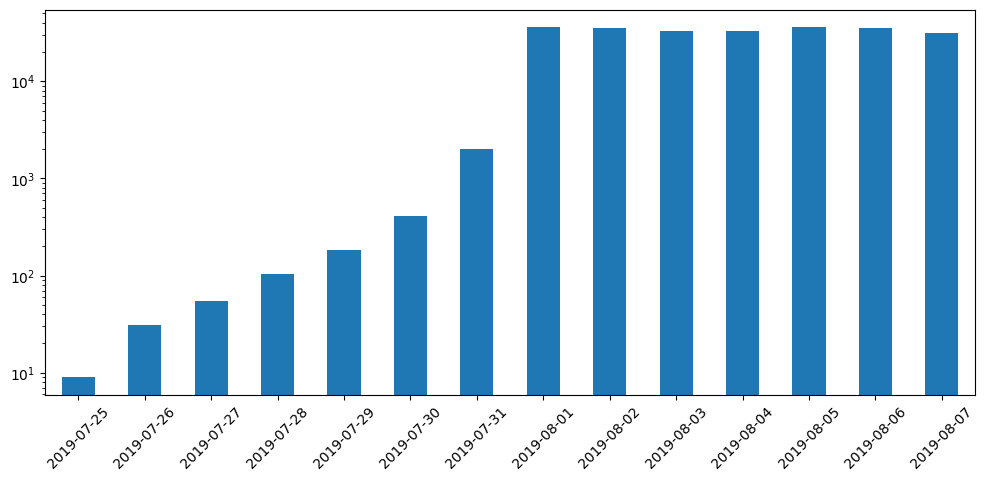

In [ ]:
events_by_date.index = events_by_date.index.strftime('%Y-%m-%d')
events_by_date.plot(kind='bar', figsize=(12, 5), logy=True)

plt.title('Number of events by date')
plt.xlabel('Date')
plt.ylabel('Number of events (log scale)')
plt.xticks(rotation=45)
plt.show()

### Chart Analysis

The chart shows that the volume of events logged in the first few days of the period is very low compared to the following days. Starting **August 1st**, there's a sharp increase in the number of events, which then stays at a high and relatively stable level until the end of the period.

This pattern indicates that records before **August 1st** represent an initial period with incomplete data, while records from **August 1–7** show a much larger and more consistent volume of events.

For that reason, the period from **August 1–7, 2019** will be treated as the complete, representative period for the analyses that follow.

### 3.7 Event Distribution Over Time

Besides the distribution of events by date, let's analyze how events are distributed across the hours of the day.

This helps identify the periods when users are more or less active in the app. To make these patterns easier to see, we plot the number of events logged in each hour.

In [ ]:
events_by_hour = logs['event_datetime'].dt.hour.value_counts().sort_index()
events_by_hour

### Event Distribution by Hour Analysis

The distribution of events across the 24 hours shows activity throughout the day, though at different levels.

There's a gradual increase in the number of events during the morning, with the highest concentration between late morning and afternoon. The largest volume of records occurs at **2 PM, with 18,109 events**, followed by 3 PM, with **18,051 events**.

After 4 PM, there's a progressive decrease in the number of events, with a sharper drop during the night and early morning hours.

*Note: event timestamps are in UTC, as logged, so "morning"/"afternoon" here follow UTC hours.*

This distribution shows that users are most active in the app during the daytime, especially between late morning and the afternoon.

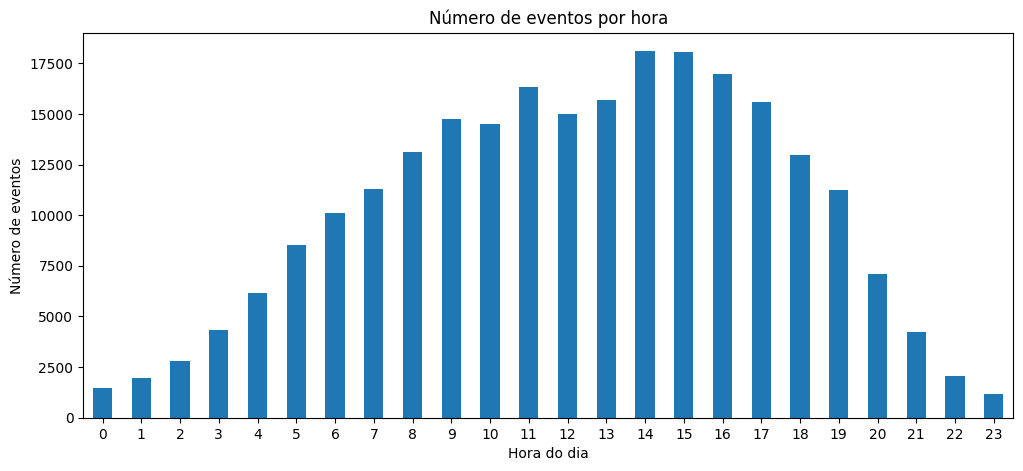

In [ ]:
events_by_hour.plot(kind='bar', figsize=(12, 5))

plt.title('Number of events by hour')
plt.xlabel('Hour of day (UTC)')
plt.ylabel('Number of events')
plt.xticks(rotation=0)
plt.show()

### Chart Analysis

The chart shows that user activity varies noticeably throughout the day. The number of events increases gradually during the morning, reaching its highest volumes between roughly **2 PM and 4 PM**.

After that, there's a progressive decrease in the number of events, especially from **5 PM** onward, with much lower volumes overnight and in the early morning.

So the app's busiest period is the afternoon, while nighttime and early-morning hours see the lowest event volume.

### 3.8 Selecting the Period with Complete Data

Based on the event distribution by date, we found that records before August 1, 2019 have a much lower volume than the following days, indicating an incomplete collection period.

To keep these records from affecting the funnel and A/A/B test analyses, we create a new DataFrame containing only the events logged from **August 1, 2019** onward.

In [ ]:
logs_full = logs[logs['event_date'] >= pd.to_datetime('2019-08-01')].copy()

In [ ]:
logs_full.head()

,event_name,user_id,event_timestamp,exp_id,event_datetime,event_date
2826,Tutorial,3737462046622621720,1564618048,246,2019-08-01 00:07:28,2019-08-01
2827,MainScreenAppear,3737462046622621720,1564618080,246,2019-08-01 00:08:00,2019-08-01
2828,MainScreenAppear,3737462046622621720,1564618135,246,2019-08-01 00:08:55,2019-08-01
2829,OffersScreenAppear,3737462046622621720,1564618138,246,2019-08-01 00:08:58,2019-08-01
2830,MainScreenAppear,1433840883824088890,1564618139,247,2019-08-01 00:08:59,2019-08-01


### 3.9 Events Excluded by the Period Cutoff

After defining the period with complete data, let's compare the total number of events in the original dataset with the number of events kept in the selected period.

This comparison quantifies how many records were excluded for belonging to the incomplete period.

In [ ]:
logs.shape[0] - logs_full.shape[0]

2826

### 3.10 Users Excluded by the Period Cutoff

Besides events, we also need to check how many unique users appear only in records before August 1st. This lets us assess whether the period cutoff also causes a meaningful loss of users for the analysis.

In [ ]:
logs['user_id'].nunique() - logs_full['user_id'].nunique()

17

### 3.11 Impact of the Cutoff on the Dataset

Let's calculate the percentage of events and users excluded relative to the original dataset. This lets us gauge the size of the loss caused by removing the incomplete period.

In [ ]:
users_before = logs['user_id'].nunique()
users_after = logs_full['user_id'].nunique()

events_lost_pct = (logs.shape[0] - logs_full.shape[0]) / logs.shape[0] * 100
users_lost_pct = (users_before - users_after) / users_before * 100

events_lost_pct, users_lost_pct

### Period Cutoff Impact Analysis

Excluding records before August 1, 2019 removed **2,826 events**, about **1.16%** of all logged events.

For users, **17 users** were excluded, about **0.23%** of all users.

The data loss is therefore relatively small, especially in terms of users. Since the earlier records show the characteristics of an incomplete collection period, excluding that window is appropriate for keeping the analyses that follow consistent.

After the cutoff, the data used in the analyses that follow represents the period from **August 1–7, 2019**.

### 3.12 Checking the Experimental Groups

After the period cutoff, let's check whether the data still contains users from all three experimental groups.

We do this by counting the number of **unique users** (`user_id`) in each group (`exp_id`). This confirms that groups **246, 247, and 248** are all represented in the data used in the analyses that follow.

In [ ]:
users_by_group = logs_full.groupby('exp_id')['user_id'].nunique()

users_by_group

exp_id
246    2484
247    2513
248    2537
Name: user_id, dtype: int64

### Experimental Groups Analysis

The check confirms that all three experimental groups are represented in the data after the period cutoff.

Group **246** has **2,484 users**, group **247** has **2,513 users**, and group **248** has **2,537 users**.

So all groups have enough users to run the A/A/B test analyses in the steps that follow.

### Data Study and Verification Conclusion

The initial check identified **243,713 logged events for 7,551 users**, an average of roughly **32.28 events per user**.

The time distribution of records showed that the period from July 25–31, 2019 had a significantly lower data volume than the following days. Because of this, we treat **August 1, 2019 as the start of the period with complete data** and disregard records before that date.

The cutoff excluded **2,826 events (1.16%)** and **17 users (0.23%)**, a relatively small loss compared to the original dataset.

After filtering, all three experimental groups remained represented: **2,484 users in group 246, 2,513 in group 247, and 2,537 in group 248**.

The dataset therefore has enough volume and representation across all three experimental groups to move on to the funnel analysis and, later, the A/A/B test.

## 4. Funnel Analysis

With the complete-data period defined and validated, we can start the funnel analysis.

In this step, we study the sequence of actions users take in the app, identifying which events are part of the purchase journey and at which stages the largest user drop-off occurs.

First, let's identify **which events are logged in the complete period and how many times each occurred**.

In [ ]:
logs_full['event_name'].value_counts()

MainScreenAppear           117328
OffersScreenAppear          46333
CartScreenAppear            42303
PaymentScreenSuccessful     33918
Tutorial                     1005
Name: event_name, dtype: int64

### 4.1.1 Number of Users per Event

The number of times an event occurs doesn't tell us how many users took that step, since the same user can perform the same event multiple times.

So we calculate the number of unique users who performed each type of event. This is what we use to determine the share of users who move through each stage of the funnel.

In [ ]:
logs_full.groupby('event_name')['user_id'].nunique().sort_values(ascending=False)

event_name
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Tutorial                    840
Name: user_id, dtype: int64

### 4.1.2 Share of Users per Event

To compare the funnel stages, let's calculate the share of users who performed each event relative to the total number of users in the complete period.

This metric shows what percentage of the user base reached each stage of the journey.

In [ ]:
users_total = logs_full['user_id'].nunique()

users_by_event = logs_full.groupby('event_name')['user_id'].nunique()

(users_by_event / users_total * 100).sort_values(ascending=False)

### 4.2 Funnel Event Order

Based on the number of users who performed each event, we can identify the main stages of the purchase journey.

The expected sequence for the purchase process is:

1. `MainScreenAppear` — main screen view;
2. `OffersScreenAppear` — offers screen view;
3. `CartScreenAppear` — cart access;
4. `PaymentScreenSuccessful` — successful payment.

The `Tutorial` event is analyzed separately, since it's an optional interaction rather than a required step to complete a purchase.

Next, we calculate the conversion between **consecutive funnel steps**, to identify where the biggest user drop-off happens.

### 4.3 Conversion Between Funnel Steps

Now let's analyze the conversion between consecutive steps of the sales funnel.

First, let's pull the number of unique users at each of the four main steps of the purchase journey, in the order they occur.

In [ ]:
funnel = users_by_event[
    [
        'MainScreenAppear',
        'OffersScreenAppear',
        'CartScreenAppear',
        'PaymentScreenSuccessful'
    ]
]

funnel

event_name
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Name: user_id, dtype: int64

### 4.3.1 Conversion Rate Between Steps

To make the funnel easier to read, let's calculate the conversion rate between each consecutive step. The value represents the share of users who moved from the previous step to the next.

In [ ]:
conversion = (funnel / funnel.shift(1) * 100).round(2)

conversion

event_name
MainScreenAppear             NaN
OffersScreenAppear         61.91
CartScreenAppear           81.30
PaymentScreenSuccessful    94.78
Name: user_id, dtype: float64

### Conversion Between Steps Analysis

The conversion rates show that **61.91%** of users who viewed the main screen moved on to the offers screen. This is the step with the largest user drop-off, a loss of roughly **38.09%**.

Between the offers screen and the cart, the conversion rate was **81.30%**, a loss of about 18.70% of users.

Finally, **94.78%** of users who reached the cart went on to complete their payment, the smallest loss among all steps.

So the main opportunity for improvement in the funnel is the transition between the **main screen and the offers screen**, where the largest proportional user drop-off occurs.

### 4.4 Conversion from the First Event to Payment

Now let's calculate the overall funnel conversion, using as the starting point the number of users who performed the first event of the purchase journey (`MainScreenAppear`) and as the endpoint the users who reached a successful payment (`PaymentScreenSuccessful`).

This metric tells us how many users who started the journey actually reached the final purchase step.

In [ ]:
funnel['PaymentScreenSuccessful'] / funnel['MainScreenAppear'] * 100

47.70184661005526

### Overall Funnel Conversion Analysis

Taking users who viewed the main screen as the starting point of the journey, the conversion to a completed payment was **47.70%**.

That means roughly **47.7% of users who started the purchase journey reached the final payment step**.

The largest drop-off happens between the main screen and the offers screen, while later steps show progressively higher conversion rates. So the first transition is the main point of attention in the conversion funnel.

### 4.5 Cumulative Funnel Conversion

To complement the step-to-step conversion analysis, let's calculate the share of users who reached each step relative to the first funnel event (`MainScreenAppear`).

This lets us see the cumulative user loss along the journey, from viewing the main screen through to a completed payment.

In [ ]:
funnel_cumulative = (funnel / funnel['MainScreenAppear'] * 100).round(2)

funnel_cumulative

event_name
MainScreenAppear           100.00
OffersScreenAppear          61.91
CartScreenAppear            50.33
PaymentScreenSuccessful     47.70
Name: user_id, dtype: float64

### Cumulative Funnel Conversion Analysis

Using users who performed the `MainScreenAppear` event as the baseline, **61.91%** moved on to the offers screen, **50.33%** reached the cart, and **47.70%** reached a completed payment.

The cumulative conversion confirms that the largest loss happens early in the journey, between viewing the main screen and reaching the offers screen. After that step, the step-to-step conversion rate increases (61.91% → 81.30% → 94.78%), which is why each additional stage loses a smaller share of the *remaining* users, even though the cumulative share of the original user base keeps falling at every step.

By the end of the process, roughly **47.70% of users who reached the main screen completed their payment**.

### 4.6 Verifying the Event Order

To confirm the funnel step sequence, let's analyze the order in which events appear in each user's records.

The sequence considered so far is:

`MainScreenAppear → OffersScreenAppear → CartScreenAppear → PaymentScreenSuccessful`

This check lets us assess whether this order properly represents the purchase journey observed in the data.

In [ ]:
user_events = logs_full.groupby('user_id')['event_name'].agg(list)

user_events.head()

### 4.6.1 First Occurrence of Each Event per User

To analyze the sequence of user interactions with the app, let's identify the first occurrence of each event for each user.

First, records are sorted chronologically and grouped by user and event type. Then we take the first record of each combination.

Besides looking at a few individual records in chronological order, we calculate the mean time of the first occurrence of each event. This lets us check whether the order observed in the data is consistent with the sequence assumed in the funnel.

In [ ]:
logs_sorted = logs_full.sort_values(['user_id', 'event_datetime'])

first_events = (
    logs_sorted
    .groupby(['user_id', 'event_name'])
    .first()
    .reset_index()
)

first_events = first_events.sort_values(['user_id', 'event_datetime'])

first_events.head(20)

In [ ]:
mean_first_event_time = (
    first_events
    .groupby('event_name')['event_timestamp']
    .mean()
    .sort_values()
)

mean_first_event_time = pd.to_datetime(mean_first_event_time, unit='s')

mean_first_event_time

event_name
MainScreenAppear          2019-08-02 18:48:54.188030720
OffersScreenAppear        2019-08-02 22:57:08.290006528
CartScreenAppear          2019-08-03 00:54:01.852972800
PaymentScreenSuccessful   2019-08-03 01:49:33.465668096
Tutorial                  2019-08-04 01:15:33.951190528
Name: event_timestamp, dtype: datetime64[ns]

### First Event Occurrence Analysis

The mean time of the first occurrence of each event shows that, on average, the main events follow the sequence assumed for the funnel: `MainScreenAppear`, `OffersScreenAppear`, `CartScreenAppear`, and `PaymentScreenSuccessful`.

The mean first occurrence of `MainScreenAppear` happens on **August 2 at 18:48**, followed by `OffersScreenAppear`, also on August 2, at **22:57**, `CartScreenAppear` on **August 3 at 00:54**, and `PaymentScreenSuccessful` on **August 3 at 01:49**.

The `Tutorial` event has a mean first occurrence only on **August 4**, indicating it doesn't necessarily follow the main funnel sequence and should be treated separately.

While the average order of the main events matches the assumed funnel sequence, looking at individual users shows that some perform events out of that order. So the sequence shown here represents a general journey structure, not a strict order followed by every user.

### Funnel Analysis Conclusion

The funnel analysis showed that the main purchase journey can generally be described by the sequence `MainScreenAppear → OffersScreenAppear → CartScreenAppear → PaymentScreenSuccessful`. The first-event-occurrence analysis indicates this order is consistent with average user behavior, though some individual users perform events in a different order.

Of the users who viewed the main screen, **61.91%** moved on to the offers screen, **81.30%** of users who reached the offers screen moved on to the cart, and **94.78%** of users who reached the cart completed their payment.

Across the whole journey, the conversion between viewing the main screen and completing a payment was **47.70%**.

The largest drop-off happened in the transition between `MainScreenAppear` and `OffersScreenAppear`, making it the main point of attention identified in the funnel analysis. The `Tutorial` event was analyzed separately since it isn't a required step in the purchase process.

With the purchase journey and its main drop-off points identified, we can move on to the A/A/B test analysis and check whether the font change produced any statistically significant shift in user behavior.

## 5. A/A/B Test Analysis

Having analyzed the event funnel, let's now evaluate the results of the A/A/B test run in the app.

Users were split into three experimental groups:
- **246** — first control group (old fonts);
- **247** — second control group (old fonts);
- **248** — test group (new fonts).

First, let's check the number of users in each group. This lets us assess whether the groups are comparable in size before running the statistical tests.

In [ ]:
logs_full.groupby('exp_id')['user_id'].nunique()

### User Distribution Across Groups Analysis

The three experimental groups have similar numbers of users: 2,484 in the first control group (246), 2,513 in the second control group (247), and 2,537 in the test group (248).

The difference between groups is small, indicating a relatively balanced user split. This matters for the experiment, since it reduces the risk that differences in results could simply be explained by a large discrepancy in sample sizes.

Next, we compare the two control groups (246 and 247) to check whether they show statistically significant behavioral differences, confirming that the split between groups was done correctly.

### 5.1 Checking the Control Groups (A/A)

Before evaluating the effect of the new fonts, we need to check whether the two control groups, 246 and 247, behave similarly.

Since both used the old fonts, we don't expect to find statistically significant differences between them. This comparison lets us check whether the split of users between the two control groups was done properly.

First, let's compare the number of users who performed each type of event in the two control groups.

In [ ]:
control_events = logs_full[logs_full['exp_id'].isin([246, 247])]

control_events.groupby(['event_name', 'exp_id'])['user_id'].nunique().unstack()

### 5.2 Statistical Test Between the Control Groups

To check whether the two control groups show statistically significant differences, we compare the share of users who performed each event relative to each group's total.

The null hypothesis is that **there is no statistically significant difference between groups 246 and 247** for the event being analyzed.

The alternative hypothesis is that **there is a statistically significant difference between the two groups**.

We use a two-proportion statistical test, with a significance level of **5% (α = 0.05)**.

In [ ]:
n_246 = logs_full[logs_full['exp_id'] == 246]['user_id'].nunique()
n_247 = logs_full[logs_full['exp_id'] == 247]['user_id'].nunique()
n_248 = logs_full[logs_full['exp_id'] == 248]['user_id'].nunique()

n_246, n_247, n_248

### 5.2.1 Share of Users per Event in the Control Groups

To compare the control groups properly, let's calculate the share of users in each group who performed each event.

Using shares instead of raw counts accounts for the small difference in sample size between groups 246 and 247.

In [ ]:
control_users = control_events.groupby(['event_name', 'exp_id'])['user_id'].nunique().unstack()

control_proportions = control_users.copy()

control_proportions[246] = control_users[246] / n_246
control_proportions[247] = control_users[247] / n_247

control_proportions

### 5.2.2 Significance Test for the Control Groups

Let's test, for each event, whether the difference observed between the proportions of groups 246 and 247 is statistically significant.

For each comparison:

- **Null hypothesis (H₀):** the share of users who performed the event is the same in both control groups;
- **Alternative hypothesis (H₁):** the shares are different between the two control groups;
- **Significance level:** α = 0.05.

We use a two-proportion z-test (`proportions_ztest`). This test is appropriate because we're comparing the share of users who performed a given event between two independent groups, treating each user's outcome as binary: performed the event or didn't.

If the p-value is below 0.05, we reject the null hypothesis and consider there to be a statistically significant difference between groups for that event.

First, let's run the test for the `MainScreenAppear` event.

In [ ]:
count = np.array([
    control_users.loc['MainScreenAppear', 246],
    control_users.loc['MainScreenAppear', 247]
])

nobs = np.array([n_246, n_247])

z_stat, p_value = proportions_ztest(count, nobs)

z_stat, p_value

### 5.2.3 A Reusable Function for All Comparisons

Since we're going to run this same two-proportion test repeatedly, across every event and every pair of groups (including the combined control group later on), we wrap it in a single reusable function, `test_proportions`.

The function accepts a single `exp_id` or a list of `exp_id`s for either side of the comparison, which lets us reuse it for the combined-control-group comparisons in section 5.4 as well.

In [ ]:
def test_proportions(event, group1, group2):
    """
    Runs a two-proportion z-test comparing the share of users who
    performed `event` in group1 vs. group2.

    group1 / group2 can each be a single exp_id (e.g. 246) or a list
    of exp_ids to be combined into one group (e.g. [246, 247]).

    Returns (z_stat, p_value).
    """
    def users_in(groups):
        if not isinstance(groups, (list, tuple)):
            groups = [groups]
        subset = logs_full[logs_full['exp_id'].isin(groups)]
        n_total = subset['user_id'].nunique()
        n_event = subset[subset['event_name'] == event]['user_id'].nunique()
        return n_event, n_total

    count1, n1 = users_in(group1)
    count2, n2 = users_in(group2)

    z_stat, p_value = proportions_ztest(
        np.array([count1, count2]),
        np.array([n1, n2])
    )
    return z_stat, p_value

In [ ]:
control_pvalues = pd.Series(
    {
        event: test_proportions(event, 246, 247)[1]
        for event in control_users.index
    }
)

control_pvalues

### A/A Test Results Analysis

The statistical tests between the two control groups found no statistically significant differences in any of the events analyzed.

All p-values were above the significance level of **0.05**, so we don't reject the null hypothesis in any of the comparisons.

This means groups 246 and 247 behave in a statistically similar way. So the two control groups can be considered **comparable** and used as the reference for the comparison with the test group 248.

### 5.3 Comparing the Test Group Against Each Control Group and the Combined Control

Now let's compare the test group **248**, which used the new fonts, against: the first control group (**246**), the second control group (**247**), and the two control groups combined (**246 + 247**, which is valid since section 5.2 found no significant difference between them).

We reuse the `test_proportions` function from section 5.2.3 for all of these comparisons, running it in a loop across every event and every group pairing instead of repeating the same test-and-interpret block by hand for each one. This keeps all of the test group's comparisons — together with the A/A comparison from section 5.2 — in a single results table, which we use again in section 5.4 for the Bonferroni correction.

The same hypotheses and significance level (α = 0.05) from the previous section apply to every comparison below.

In [ ]:
events = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful',
    'Tutorial'
]

comparisons = {
    '246 vs 247 (A/A)': (246, 247),
    '246 vs 248': (246, 248),
    '247 vs 248': (247, 248),
    '246+247 (combined) vs 248': ([246, 247], 248),
}

results = []
for label, (group1, group2) in comparisons.items():
    for event in events:
        z_stat, p_value = test_proportions(event, group1, group2)
        results.append({
            'comparison': label,
            'event': event,
            'z_stat': z_stat,
            'p_value': p_value
        })

pvalues_table = pd.DataFrame(results)
pvalues_table

### Test vs. Control Comparisons Analysis

Looking only at the three comparisons that involve the test group 248 (246 vs 248, 247 vs 248, and the combined control vs 248), every p-value is well above **0.05** — the smallest is about **0.078** (`CartScreenAppear`, group 246 vs 248), and the largest is about **0.92** (`OffersScreenAppear`, group 247 vs 248).

So none of the 15 test-vs-control comparisons show a statistically significant difference. For every funnel event, using the new fonts in group 248 did not produce a statistically significant change in user behavior relative to either control group individually or to the combined control group.

Combined with the A/A result from section 5.2 (where the two control groups also showed no significant difference from each other), this gives a consistent picture: up to this point in the analysis, **there is no statistical evidence that the font change affected user behavior**.

### 5.4 Correcting for Multiple Comparisons

Across the full A/A/B analysis, we ran **20 statistical hypothesis tests**: 5 events × 4 group comparisons (246 vs 247, 246 vs 248, 247 vs 248, and combined control vs 248) — exactly the 20 rows in `pvalues_table` above.

Since we ran multiple comparisons, we apply the **Bonferroni correction** to control the probability of finding a "significant" result purely by chance.

Starting from the initial significance level of **0.05** and the **20 tests performed**, the adjusted significance level is:

**α = 0.05 / 20 = 0.0025**

So, for the comparisons in this A/A/B test, we only treat a result as statistically significant when its p-value is **below 0.0025**.

In [ ]:
total_tests = len(pvalues_table)
alpha = 0.05
bonferroni_alpha = alpha / total_tests

total_tests, bonferroni_alpha

### Multiple Comparisons Correction Analysis

Across the full A/A/B analysis, we ran **20 statistical hypothesis tests** (5 events × 4 group comparisons). Running multiple tests increases the chance of finding a "significant" result by chance alone, so we apply the **Bonferroni correction**.

Starting from a significance level of **0.05**, the adjusted level is calculated by dividing it by the total number of tests:

**α = 0.05 / 20 = 0.0025**

From this point on, a result is only considered statistically significant if its p-value is **below 0.0025**.

### 5.4.1 Checking All 20 Results Against the Adjusted Significance Level

Now let's flag, directly in `pvalues_table`, which of the 20 tests — across all four group comparisons — remain significant once we apply the Bonferroni-adjusted threshold of **0.0025**.

In [ ]:
pvalues_table['significant_at_0.05'] = pvalues_table['p_value'] < alpha
pvalues_table['significant_after_bonferroni'] = pvalues_table['p_value'] < bonferroni_alpha

pvalues_table

In [ ]:
pvalues_table['significant_after_bonferroni'].value_counts()

### Adjusted Significance Level Results Analysis

After comparing all 20 p-values against the Bonferroni-adjusted level of **0.0025**, none of them come out as statistically significant — in fact, not one of the 20 tests was even significant at the original, less strict **0.05** level.

So even after correcting for multiple comparisons, **there is no statistical evidence that the font change caused a significant shift in user behavior**.

### A/A/B Test Results Conclusion

Across all four group comparisons (246 vs 247, 246 vs 248, 247 vs 248, and the combined control vs 248), none of the 20 individual tests found a statistically significant difference in any of the five events analyzed.

Every p-value stayed above the original significance level of **0.05**, and all of them remained above the Bonferroni-adjusted level of **0.0025** after correcting for the 20 tests run across the full A/A/B analysis.

So the analysis shows no statistical evidence that using the new fonts changed user behavior in a significant way, at any stage analyzed. The individual comparisons with groups 246 and 247, and the comparison with the combined control group, all point to the same conclusion: **the font change did not produce a statistically significant impact on user behavior**.

## Overall A/A/B Test Conclusion

The A/A/B test analysis compared the two control groups against each other, then compared the test group against each control group individually and against the combined control group.

The comparison between groups 246 and 247 found no statistically significant differences in any of the events analyzed, indicating that the two groups using the old fonts behaved in a statistically similar way.

The comparisons of the test group 248 against the control groups also found no statistically significant differences in any event, whether looking at the control groups individually or combined.

After applying the Bonferroni correction for the **20 hypothesis tests** run across the full A/A/B analysis, none of the results had a p-value below the adjusted significance level of **0.0025**.

So, based on the data analyzed, **no statistical evidence was found that the font change caused a significant shift in user behavior**. The hypothesis that the new fonts would produce a measurable impact on user behavior was not confirmed by the experiment's results.

# Final Conclusion

This analysis looked at both the users' purchase journey and the impact of the font change in the app.

In the sales funnel, **98.47%** of users viewed the main screen, **60.96%** reached the offers screen, **49.56%** accessed the cart, and **46.97%** completed a payment. Taking users who viewed the main screen as the starting point, conversion to payment was roughly **47.70%**.

The largest drop-off happened in the transition between `MainScreenAppear` and `OffersScreenAppear`: about **38.09%** of users who viewed the main screen did not move on to the offers screen. This step is the main point of attention identified in the purchase journey, while later steps showed higher conversion rates.

In the A/A/B test, the two control groups (246 and 247) behaved in a statistically similar way, with no significant differences found between them. The comparisons of the test group 248 against each control group and against the combined control group also found no statistically significant differences in any event analyzed.

After applying the Bonferroni correction for the **20 hypothesis tests** run across the full A/A/B analysis, the significance level was adjusted to **0.0025**. Results remained non-significant after this correction.

So, **no statistical evidence was found that the font change caused a significant shift in user behavior**.

Overall, the results indicate that the app's main point of attention is the transition from the main screen to the offers screen. On the other hand, the data analyzed provides no evidence that the font change significantly affected user behavior during the period studied.